In [2]:
import pandas as pd
import numpy as np
import json
import warnings
import os

warnings.filterwarnings('ignore')

In [3]:
import json
input_json_path = 'Datasets/acndata_sessions.json'
output_csv_path = 'Datasets/acndata_sessions.csv'

with open(input_json_path, 'r') as file:
    data = json.load(file)

df = pd.json_normalize(data["_items"])
df.to_csv(output_csv_path, index=False) 
print(f"Data has been successfully converted from {input_json_path} to {output_csv_path}.")
df_acn = pd.read_csv('Datasets/acndata_sessions.csv')

Data has been successfully converted from Datasets/acndata_sessions.json to Datasets/acndata_sessions.csv.


In [4]:
df_urban_time = pd.read_csv('Datasets/time.csv')
df_urban_info = pd.read_csv('Datasets/information.csv')
df_urban_occ = pd.read_csv('Datasets/occupancy.csv')
df_urban_vol = pd.read_csv('Datasets/volume.csv')

print("df_urban_time shape:", df_urban_time.shape)
print("df_urban_info shape:", df_urban_info.shape)
print("df_urban_occ shape: ", df_urban_occ.shape)
print("df_urban_vol shape: ", df_urban_vol.shape)

df_urban_time shape: (8640, 6)
df_urban_info shape: (247, 10)
df_urban_occ shape:  (8640, 248)
df_urban_vol shape:  (8640, 248)


In [5]:
df_urban_time.head()

,month,day,year,hour,minute,second
0,6,19,2022,0,0,0
1,6,19,2022,0,5,0
2,6,19,2022,0,10,0
3,6,19,2022,0,15,0
4,6,19,2022,0,20,0


In [6]:
df_urban_time['datetime'] = pd.to_datetime(df_urban_time[['year', 'month', 'day', 'hour', 'minute']])
df_urban_time['timestamp_id'] = range(1, len(df_urban_time) + 1)

In [7]:
df_urban_time.head()

,month,day,year,hour,minute,second,datetime,timestamp_id
0,6,19,2022,0,0,0,2022-06-19 00:00:00,1
1,6,19,2022,0,5,0,2022-06-19 00:05:00,2
2,6,19,2022,0,10,0,2022-06-19 00:10:00,3
3,6,19,2022,0,15,0,2022-06-19 00:15:00,4
4,6,19,2022,0,20,0,2022-06-19 00:20:00,5


In [8]:
df_urban_occ.head()

,timestamp,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,1,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
1,2,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
2,3,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,164,10,1,8,15
3,4,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,166,10,1,8,15
4,5,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,168,10,1,8,15


In [9]:
df_urban_vol.head()

,timestamp,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,1,2.858333,5.907222,6.478889,5.145,2.286667,3.048889,5.526111,0.381111,0.762222,...,0.0,2.286667,0.381111,12.195556,8.956111,240.236111,5.335556,0.381111,2.286667,2.096111
1,2,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,367.708333,8.166667,0.583333,3.500000,3.208333
2,3,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,367.708333,8.166667,0.583333,3.500000,3.208333
3,4,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,426.641667,8.166667,0.583333,3.500000,3.208333
4,5,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,452.708333,8.166667,0.583333,3.500000,3.208333


In [10]:
df_occ_long = df_urban_occ.melt(id_vars='timestamp', var_name='grid', value_name='occupancy_count')
df_vol_long = df_urban_vol.melt(id_vars='timestamp', var_name='grid', value_name='energy_volume_kwh')

print("New long occupancy shape:", df_occ_long.shape)
print("New long volume shape:   ", df_vol_long.shape)

New long occupancy shape: (2134080, 3)
New long volume shape:    (2134080, 3)


In [11]:
df_urban_vol.head()

,timestamp,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,1,2.858333,5.907222,6.478889,5.145,2.286667,3.048889,5.526111,0.381111,0.762222,...,0.0,2.286667,0.381111,12.195556,8.956111,240.236111,5.335556,0.381111,2.286667,2.096111
1,2,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,367.708333,8.166667,0.583333,3.500000,3.208333
2,3,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,367.708333,8.166667,0.583333,3.500000,3.208333
3,4,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,426.641667,8.166667,0.583333,3.500000,3.208333
4,5,4.375000,9.041667,9.916667,7.875,3.500000,4.666667,8.458333,0.583333,1.166667,...,0.0,3.500000,0.583333,18.666667,13.708333,452.708333,8.166667,0.583333,3.500000,3.208333


In [12]:
df_occ_long['grid'] = df_occ_long['grid'].astype(int)
df_vol_long['grid'] = df_vol_long['grid'].astype(int)


df_urban_merged = pd.merge(df_occ_long, df_vol_long, on=['timestamp', 'grid'])
df_urban_merged = pd.merge(df_urban_merged, df_urban_time[['timestamp_id', 'datetime']], left_on='timestamp', right_on='timestamp_id')


df_urban_final = pd.merge(df_urban_merged, df_urban_info[['grid', 'count', 'CBD']], on='grid')


df_urban_final['charger_utilization_rate'] = df_urban_final['occupancy_count'] / df_urban_final['count']
df_urban_final['charger_utilization_rate'] = df_urban_final['charger_utilization_rate'].fillna(0) # Fix any zero divisions


df_urban_final.drop(columns=['timestamp', 'timestamp_id'], inplace=True)

In [13]:
df_urban_final['hour'] = df_urban_final['datetime'].dt.hour
df_urban_final['day_of_week'] = df_urban_final['datetime'].dt.day_name()

urban_cols_to_keep = ['datetime', 'grid', 'hour', 'day_of_week', 'occupancy_count', 'energy_volume_kwh', 'count', 'CBD', 'charger_utilization_rate']
df_urban_final = df_urban_final[urban_cols_to_keep]

In [14]:
df_urban_final.head()

,datetime,grid,hour,day_of_week,occupancy_count,energy_volume_kwh,count,CBD,charger_utilization_rate
0,2022-06-19 00:00:00,102,0,Sunday,12,2.858333,30,0,0.4
1,2022-06-19 00:05:00,102,0,Sunday,12,4.375000,30,0,0.4
2,2022-06-19 00:10:00,102,0,Sunday,12,4.375000,30,0,0.4
3,2022-06-19 00:15:00,102,0,Sunday,12,4.375000,30,0,0.4
4,2022-06-19 00:20:00,102,0,Sunday,12,4.375000,30,0,0.4


In [15]:
df_acn.info()

<class 'pandas.DataFrame'>
RangeIndex: 5499 entries, 0 to 5498
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               5499 non-null   str    
 1   clusterID         5499 non-null   int64  
 2   connectionTime    5499 non-null   str    
 3   disconnectTime    5499 non-null   str    
 4   doneChargingTime  5498 non-null   str    
 5   kWhDelivered      5499 non-null   float64
 6   sessionID         5499 non-null   str    
 7   siteID            5499 non-null   int64  
 8   spaceID           5499 non-null   str    
 9   stationID         5499 non-null   str    
 10  timezone          5499 non-null   str    
 11  userID            29 non-null     float64
 12  userInputs        29 non-null     str    
dtypes: float64(2), int64(2), str(9)
memory usage: 1.5 MB


In [16]:
df_acn['connectionTime'] = pd.to_datetime(df_acn['connectionTime'])
df_acn['disconnectTime'] = pd.to_datetime(df_acn['disconnectTime'])

df_acn['session_duration_hours'] = (df_acn['disconnectTime'] - df_acn['connectionTime']).dt.total_seconds() / 3600.0

In [17]:
df_acn.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs,session_duration_hours
0,5bc90cb9f9af8b0d7fe77cd2,39,2018-04-25 11:08:04,2018-04-25 13:20:10,"Wed, 25 Apr 2018 13:21:10 GMT",7.932,2_39_78_362_2018-04-25 11:08:04.400812,2,CA-496,2-39-78-362,America/Los_Angeles,NaN,NaN,2.201667
1,5bc90cb9f9af8b0d7fe77cd3,39,2018-04-25 13:45:10,2018-04-26 00:56:16,"Wed, 25 Apr 2018 16:44:15 GMT",10.013,2_39_95_27_2018-04-25 13:45:09.617470,2,CA-319,2-39-95-27,America/Los_Angeles,NaN,NaN,11.185000
2,5bc90cb9f9af8b0d7fe77cd4,39,2018-04-25 13:45:50,2018-04-25 23:04:45,"Wed, 25 Apr 2018 14:51:44 GMT",5.257,2_39_79_380_2018-04-25 13:45:49.962001,2,CA-489,2-39-79-380,America/Los_Angeles,NaN,NaN,9.315278
3,5bc90cb9f9af8b0d7fe77cd5,39,2018-04-25 14:37:06,2018-04-25 23:55:34,"Wed, 25 Apr 2018 16:05:22 GMT",5.177,2_39_79_379_2018-04-25 14:37:06.460772,2,CA-327,2-39-79-379,America/Los_Angeles,NaN,NaN,9.307778
4,5bc90cb9f9af8b0d7fe77cd6,39,2018-04-25 14:40:34,2018-04-25 23:03:12,"Wed, 25 Apr 2018 17:40:30 GMT",10.119,2_39_79_381_2018-04-25 14:40:33.638896,2,CA-490,2-39-79-381,America/Los_Angeles,NaN,NaN,8.377222


In [18]:
acn_cols_to_keep = ['connectionTime', 'disconnectTime', 'kWhDelivered', 'stationID', 'spaceID', 'session_duration_hours']
df_acn = df_acn[acn_cols_to_keep]

In [19]:
df_acn.head()

,connectionTime,disconnectTime,kWhDelivered,stationID,spaceID,session_duration_hours
0,2018-04-25 11:08:04,2018-04-25 13:20:10,7.932,2-39-78-362,CA-496,2.201667
1,2018-04-25 13:45:10,2018-04-26 00:56:16,10.013,2-39-95-27,CA-319,11.185000
2,2018-04-25 13:45:50,2018-04-25 23:04:45,5.257,2-39-79-380,CA-489,9.315278
3,2018-04-25 14:37:06,2018-04-25 23:55:34,5.177,2-39-79-379,CA-327,9.307778
4,2018-04-25 14:40:34,2018-04-25 23:03:12,10.119,2-39-79-381,CA-490,8.377222


### EDA 

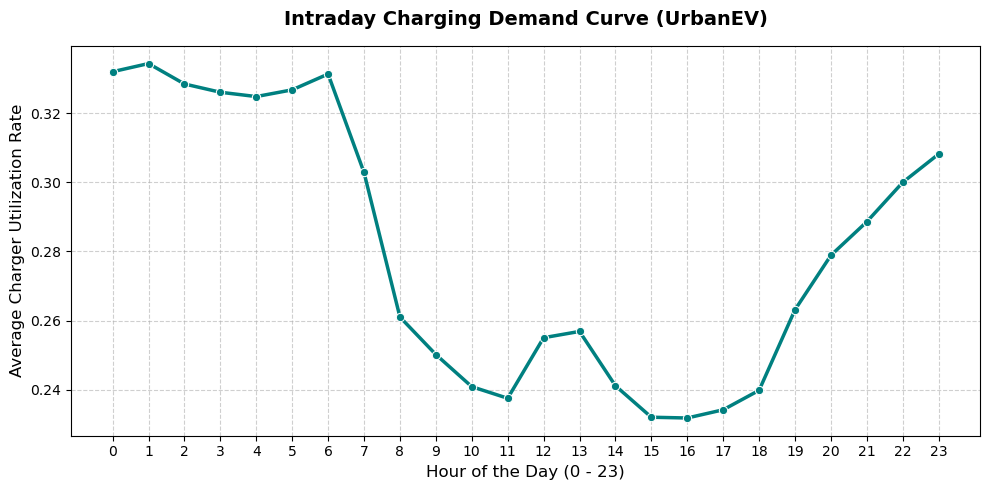

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the average utilization rate for each hour of the day across the city
hourly_demand = df_urban_final.groupby('hour')['charger_utilization_rate'].mean().reset_index()

# 2. Set up the plotting window
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_demand, x='hour', y='charger_utilization_rate', marker='o', color='teal', linewidth=2.5)

# 3. Add simple, clear titles and labels for grading presentation
plt.title('Intraday Charging Demand Curve (UrbanEV)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (0 - 23)', fontsize=12)
plt.ylabel('Average Charger Utilization Rate', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Render the plot cleanly
plt.tight_layout()
plt.show()

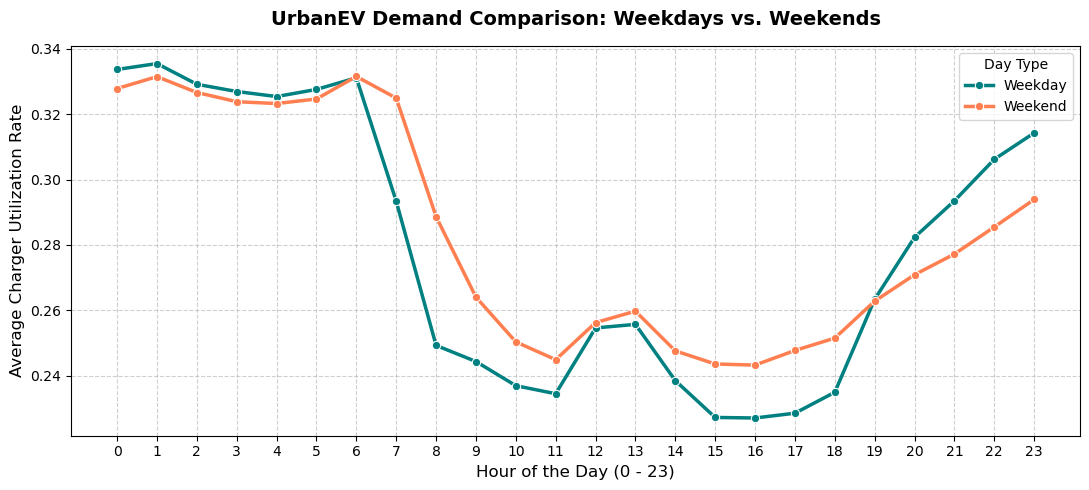

In [21]:
# 1. Create a helper column to flag rows as either 'Weekend' or 'Weekday'
df_urban_final['day_type'] = np.where(
    df_urban_final['day_of_week'].isin(['Saturday', 'Sunday']), 
    'Weekend', 
    'Weekday'
)

# 2. Group by both hour and day_type to find the average utilization rate
day_type_demand = df_urban_final.groupby(['hour', 'day_type'])['charger_utilization_rate'].mean().reset_index()

# 3. Plot the comparative line graphs
plt.figure(figsize=(11, 5))
sns.lineplot(
    data=day_type_demand, 
    x='hour', 
    y='charger_utilization_rate', 
    hue='day_type', 
    marker='o',
    palette=['teal', 'coral'], 
    linewidth=2.5
)

# 4. Add clean labels and title for grading presentation
plt.title('UrbanEV Demand Comparison: Weekdays vs. Weekends', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (0 - 23)', fontsize=12)
plt.ylabel('Average Charger Utilization Rate', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Day Type')

# 5. Display the plot
plt.tight_layout()
plt.show()

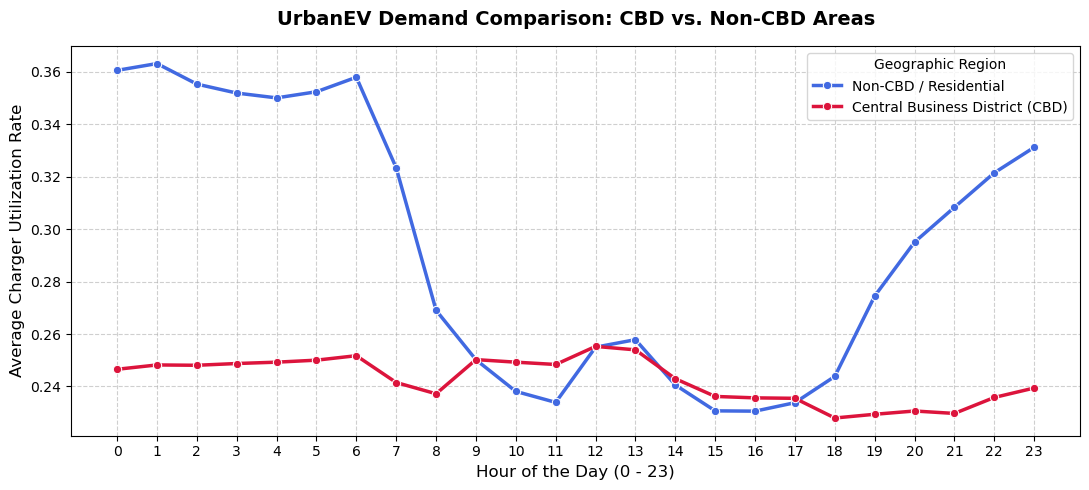

In [22]:
# 1. Group by hour and CBD to get the average utilization rate
cbd_demand = df_urban_final.groupby(['hour', 'CBD'])['charger_utilization_rate'].mean().reset_index()

# 2. Map the 0 and 1 values in CBD to reader-friendly text labels
cbd_demand['Area Type'] = cbd_demand['CBD'].map({1: 'Central Business District (CBD)', 0: 'Non-CBD / Residential'})

# 3. Plot the comparative lines
plt.figure(figsize=(11, 5))
sns.lineplot(
    data=cbd_demand, 
    x='hour', 
    y='charger_utilization_rate', 
    hue='Area Type', 
    marker='o',
    palette=['royalblue', 'crimson'], 
    linewidth=2.5
)

# 4. Add clean labels, grid, and title for submission grading
plt.title('UrbanEV Demand Comparison: CBD vs. Non-CBD Areas', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (0 - 23)', fontsize=12)
plt.ylabel('Average Charger Utilization Rate', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Geographic Region')

# 5. Render the plot cleanly
plt.tight_layout()
plt.show()

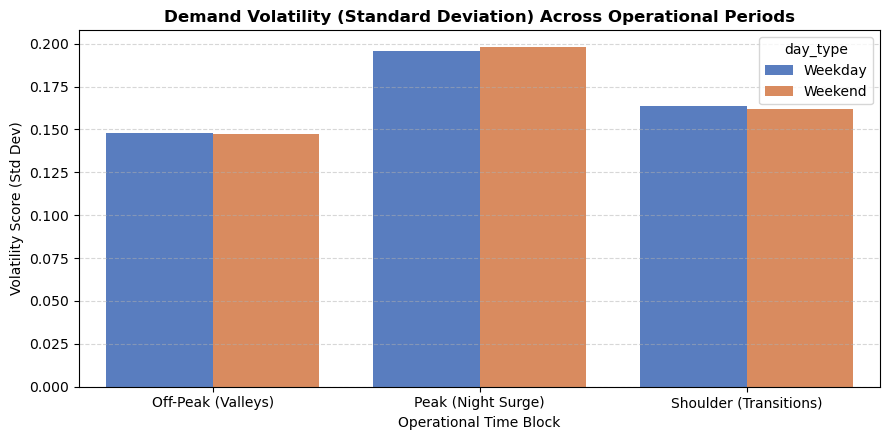

In [23]:
# 1. Define operational periods matching your true data trends
def get_period(hour):
    if 0 <= hour <= 7: return 'Peak (Night Surge)'
    elif hour in [11, 15, 16, 17]: return 'Off-Peak (Valleys)'
    else: return 'Shoulder (Transitions)'

df_urban_final['period_type'] = df_urban_final['hour'].apply(get_period)

# 2. Calculate the volatility (Standard Deviation) for each period
volatility_data = df_urban_final.groupby(['day_type', 'period_type'])['charger_utilization_rate'].std().reset_index()

# 3. Plot a clean, simple bar chart
plt.figure(figsize=(9, 4.5))
sns.barplot(data=volatility_data, x='period_type', y='charger_utilization_rate', hue='day_type', palette='muted')
plt.title('Demand Volatility (Standard Deviation) Across Operational Periods', fontsize=12, fontweight='bold')
plt.xlabel('Operational Time Block')
plt.ylabel('Volatility Score (Std Dev)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

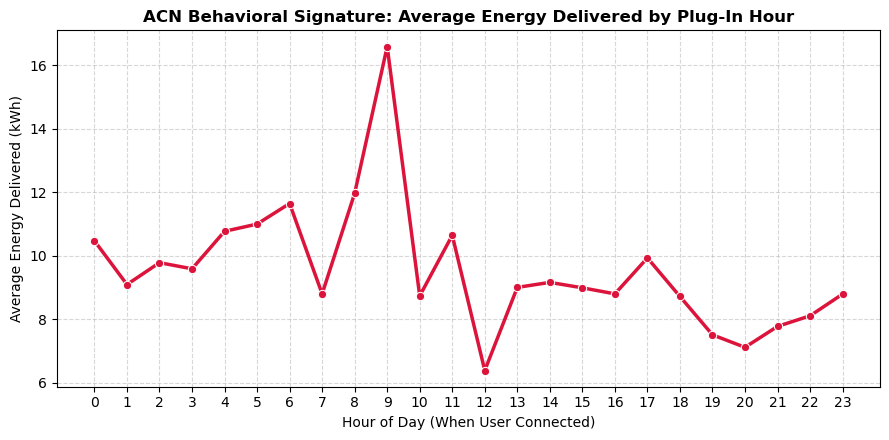

In [24]:
# 1. Extract the connection hour from the ACN dataset
df_acn['hour'] = df_acn['connectionTime'].dt.hour

# 2. Group by hour to find the average energy requested per session
acn_hourly = df_acn.groupby('hour')['kWhDelivered'].mean().reset_index()

# 3. Plot the workplace consumption behavior curve
plt.figure(figsize=(9, 4.5))
sns.lineplot(data=acn_hourly, x='hour', y='kWhDelivered', marker='o', color='crimson', linewidth=2.5)
plt.title('ACN Behavioral Signature: Average Energy Delivered by Plug-In Hour', fontsize=12, fontweight='bold')
plt.xlabel('Hour of Day (When User Connected)')
plt.ylabel('Average Energy Delivered (kWh)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Feature Extraction and Encoding

In [26]:
from sklearn.model_selection import train_test_split

print("🚀 Step 1: Extracting Target and Feature Matrices...")
# 1. Isolate target vector (y) and feature columns (X)
y_urban = df_urban_final['charger_utilization_rate']
X_urban = df_urban_final[['grid', 'hour', 'day_of_week', 'day_type', 'CBD']].copy()

print("📦 Step 2: Casting IDs and Time blocks to Categorical Text...")
# 2. Force grid, hour, and CBD to strings so they are treated as structural categories
X_urban['grid'] = X_urban['grid'].astype(str)
X_urban['hour'] = X_urban['hour'].astype(str)
X_urban['CBD'] = X_urban['CBD'].astype(str)

print("🔀 Step 3: Executing One-Hot Encoding...")
# 3. Transform categorical columns into binary columns (0 or 1 switches)
X_urban_encoded = pd.get_dummies(X_urban, columns=['grid', 'hour', 'day_of_week', 'day_type', 'CBD'], drop_first=True)

print("🧪 Step 4: Performing 80/20 Train-Test Partition...")
# 4. Split data into training sets (to study patterns) and testing sets (hidden final exam)
X_train, X_test, y_train, y_test = train_test_split(
    X_urban_encoded, 
    y_urban, 
    test_size=0.2, 
    random_state=42
)

print("\n✅ Feature Extraction and Encoding Reset Successfully!")
print(f"-> Training Matrix: {X_train.shape[0]:,} rows | {X_train.shape[1]} unique encoded feature columns")
print(f"-> Testing Matrix:  {X_test.shape[0]:,} rows")

🚀 Step 1: Extracting Target and Feature Matrices...
📦 Step 2: Casting IDs and Time blocks to Categorical Text...
🔀 Step 3: Executing One-Hot Encoding...
🧪 Step 4: Performing 80/20 Train-Test Partition...

✅ Feature Extraction and Encoding Reset Successfully!
-> Training Matrix: 1,707,264 rows | 277 unique encoded feature columns
-> Testing Matrix:  426,816 rows
